In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
data = pd.read_csv("RSMC_RAW.csv", index_col=0)
data = data.rename_axis('International number ID').reset_index()

# # Define a function to convert degrees to compass directions
# def get_compass_direction(angle):
#     directions = ['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW']
#     idx = round(angle / 45) % 8
#     return directions[idx]


# Convert the 'timestamp' column to datetime
data['Time of analysis'] = pd.to_datetime(data['Time of analysis'])

# Extract Year, Month, Day, and Hour into new columns
data['year'] = data['Time of analysis'].dt.year
data['month'] = data['Time of analysis'].dt.month
data['day'] = data['Time of analysis'].dt.day
data['hour'] = data['Time of analysis'].dt.hour

# Drop the unecessary columns
data = data.drop(columns=['Time of analysis'])
data = data.drop(columns=['Name of the storm'])

# Reposition
data.insert(1, 'year', data.pop('year'))
data.insert(2, 'month', data.pop('month'))
data.insert(3, 'day', data.pop('day'))
data.insert(4, 'hour', data.pop('hour'))
data.insert(5, 'Grade', data.pop('Grade'))

# Drop certain attricbutes
data = data.drop(data.columns[9:], axis=1)

# Calculate differences within each TC_ID group
data['Delta Latitude'] = data.groupby('International number ID')['Latitude of the center'].diff().fillna(0)
data['Delta Longitude'] = data.groupby('International number ID')['Longitude of the center'].diff().fillna(0)

# Calculate direction in radians, then convert to degrees
data['Direction Degrees'] = np.degrees(np.arctan2(data['Delta Longitude'], data['Delta Latitude']))

# Convert degrees to compass direction
# data['Compass Direction'] = data['Direction Degrees'].apply(lambda x: get_compass_direction(x))

# Apply changes inplace
data['Direction Degrees'].fillna(0, inplace=True)
# data['Compass Direction'].fillna('Unknown', inplace=True)


data.head()

,International number ID,year,month,day,hour,Grade,Latitude of the center,Longitude of the center,Central pressure,Delta Latitude,Delta Longitude,Direction Degrees
0,5101,1951,2,19,6,Tropical Depression (TD),20.0,138.5,1010,0.0,0.0,0.000000
1,5101,1951,2,19,12,Tropical Depression (TD),20.0,138.5,1010,0.0,0.0,0.000000
2,5101,1951,2,19,18,Tropical Depression (TD),23.0,142.1,1000,3.0,3.6,50.194429
3,5101,1951,2,20,0,Tropical Cyclone of TS intensity or higher,25.0,146.0,994,2.0,3.9,62.850318
4,5101,1951,2,20,6,Tropical Cyclone of TS intensity or higher,27.6,150.6,994,2.6,4.6,60.524111


In [ ]:
# Drop rows before year 1977 since they used different method to grade and record typhoons
data = data[data["year"] >= 1977]
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 43482 entries, 25268 to 68749
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   International number ID  43482 non-null  int64  
 1   year                     43482 non-null  int32  
 2   month                    43482 non-null  int32  
 3   day                      43482 non-null  int32  
 4   hour                     43482 non-null  int32  
 5   Grade                    43482 non-null  object 
 6   Latitude of the center   43482 non-null  float64
 7   Longitude of the center  43482 non-null  float64
 8   Central pressure         43482 non-null  int64  
 9   Delta Latitude           43482 non-null  float64
 10  Delta Longitude          43482 non-null  float64
 11  Direction Degrees        43482 non-null  float64
dtypes: float64(5), int32(4), int64(2), object(1)
memory usage: 3.6+ MB


In [ ]:
idx = idx = (data["Grade"] == "Just entering into the responsible area of RSMC Tokyo-Typhoon Center") | (data["Grade"] == "Extra-tropical Cyclone (L)")
data[idx].shape

(5069, 12)

In [ ]:
data = data.drop(data[idx].index)
data.shape

(38413, 12)

In [ ]:
data["Grade"].unique()

array(['Tropical Depression (TD)', 'Severe Tropical Storm (STS)',
       'Tropical Storm (TS)', 'Typhoon (TY)'], dtype=object)

In [ ]:
data = data.replace("Tropical Depression (TD)", "TD")
data = data.replace("Severe Tropical Storm (STS)", "STS")
data = data.replace("Tropical Storm (TS)", "TS")
data = data.replace("Typhoon (TY)", "TY")
data["Grade"].unique()

array(['TD', 'STS', 'TS', 'TY'], dtype=object)

In [ ]:
print (len(data))
data = data.dropna()
len(data)

38413


38413

In [ ]:
grade_map = {"TD":1, "TS":2, "STS":3, "TY":4}  #grade map using the starndard for grade Tropical Depressions of WMO
data["Grade"] = data["Grade"].map(grade_map)
data["Grade"].unique()

array([1, 3, 2, 4])

In [ ]:
data = data[data["hour"] % 6 == 0]

In [ ]:
data.head()
data.tail()

,International number ID,year,month,day,hour,Grade,Latitude of the center,Longitude of the center,Central pressure,Delta Latitude,Delta Longitude,Direction Degrees
68727,2303,2023,6,11,6,3,24.2,132.6,975,1.2,0.9,36.869898
68728,2303,2023,6,11,12,3,25.6,133.8,980,1.4,1.2,40.601295
68729,2303,2023,6,11,18,3,26.4,135.3,980,0.8,1.5,61.927513
68730,2303,2023,6,12,0,3,27.9,136.9,980,1.5,1.6,46.847610
68731,2303,2023,6,12,6,3,29.5,138.1,985,1.6,1.2,36.869898


In [ ]:
ids = data["International number ID"].unique() # Unique IDs of typhoons
typhoons = list()
for ID in ids:
    typhoon = data[data["International number ID"] == ID]
    typhoon = typhoon.drop(["International number ID"], axis=1)
    typhoons.append(typhoon)
print(len(typhoons))

1177


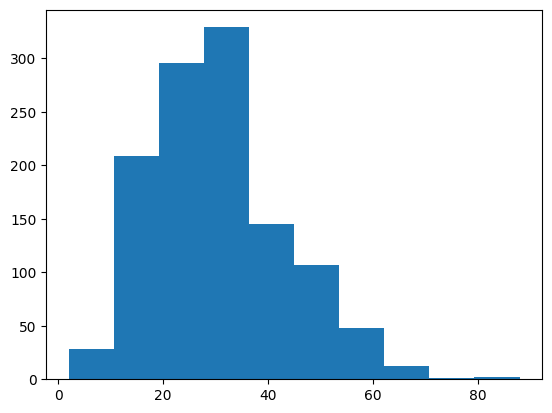

[ 28. 209. 296. 329. 145. 107.  48.  12.   1.   2.]


In [ ]:
hist = data["International number ID"].value_counts()
n = plt.hist(hist)
plt.show()
print(n[0])

In [ ]:
interval = 1
dataset = np.empty((0, 3, 11))
test_typhoons = np.empty((0,3,11))  # Preserve Some typhoons for model evaluation


for typhoon in typhoons:
    nptyphoon = np.array(typhoon)
    for i in range(0, nptyphoon.shape[0]-3, interval):
        single_data = nptyphoon[i:i+3]
        single_data = np.expand_dims(single_data, axis=0)
        if typhoon.iloc[0]["year"]>=2022:
            test_typhoons = np.append(test_typhoons, single_data, axis=0)
            continue
        dataset = np.append(dataset, single_data, axis=0)
print(dataset.shape)
print(test_typhoons.shape)



(31683, 3, 11)
(562, 3, 11)


# MACHINE LEARNING

In [ ]:
# X, Y split
x = dataset[:, :2, :]
y = dataset[:, 2, 4:] # we don't predict year, month, day, hour

# Train, Test split
from sklearn.model_selection import train_test_split
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.3, random_state=42, shuffle=True)
print(x_train.shape)
print(y_train.shape)
print(x_val.shape)
print(y_val.shape)
print(dataset)

# Set numpy print options to see more data
np.set_printoptions(threshold=np.inf, precision=4, suppress=True)
print('\n\n\n\n',x)

(22178, 2, 11)
(22178, 7)
(9505, 2, 11)
(9505, 7)
[[[ 1.97700000e+03  3.00000000e+00  2.70000000e+01 ...  0.00000000e+00
    0.00000000e+00  0.00000000e+00]
  [ 1.97700000e+03  3.00000000e+00  2.70000000e+01 ...  3.00000000e-01
   -1.00000000e+00 -7.33007558e+01]
  [ 1.97700000e+03  3.00000000e+00  2.70000000e+01 ...  5.00000000e-01
   -7.00000000e-01 -5.44623222e+01]]

 [[ 1.97700000e+03  3.00000000e+00  2.70000000e+01 ...  3.00000000e-01
   -1.00000000e+00 -7.33007558e+01]
  [ 1.97700000e+03  3.00000000e+00  2.70000000e+01 ...  5.00000000e-01
   -7.00000000e-01 -5.44623222e+01]
  [ 1.97700000e+03  3.00000000e+00  2.70000000e+01 ...  5.00000000e-01
   -5.00000000e-01 -4.50000000e+01]]

 [[ 1.97700000e+03  3.00000000e+00  2.70000000e+01 ...  5.00000000e-01
   -7.00000000e-01 -5.44623222e+01]
  [ 1.97700000e+03  3.00000000e+00  2.70000000e+01 ...  5.00000000e-01
   -5.00000000e-01 -4.50000000e+01]
  [ 1.97700000e+03  3.00000000e+00  2.80000000e+01 ...  8.00000000e-01
   -5.00000000e-01 

IOPub data rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_data_rate_limit`.

Current values:
NotebookApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
NotebookApp.rate_limit_window=3.0 (secs)



In [ ]:
# Flatten X data
x_train = x_train.reshape(-1, 22)
x_val = x_val.reshape(-1, 22)

In [ ]:
from sklearn.preprocessing import StandardScaler
scale = StandardScaler()

x_train = scale.fit_transform(x_train)
x_val = scale.transform(x_val)

# LINEAR REGRESSION

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
lr = LinearRegression()
lr.fit(x_train, y_train)
pred = lr.predict(x_train)
rmse = mean_squared_error(pred, y_train, squared=False)

print("Training Score:", rmse)

pred = lr.predict(x_val)
rmse = mean_squared_error(pred, y_val, squared=False)
print("Test Score:", rmse)

Training Score: 5.433509921811769
Test Score: 5.371154941950325


# RANDOM FOREST

In [ ]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(random_state=42)
rf.fit(x_train, y_train)
pred = rf.predict(x_train)
rmse = mean_squared_error(pred, y_train, squared=False)

print("Training Score:", rmse)

pred = rf.predict(x_val)
rmse = mean_squared_error(pred, y_val, squared=False)
print("Test Score:", rmse)

Training Score: 2.291325554212222
Test Score: 6.0776608456025345


# DEEP NEURAL NETWORK (MLP)

In [ ]:
import torch
from torch import nn
import random

random.seed(42)
torch.manual_seed(42)

x_train_t = torch.tensor(x_train, dtype=torch.float)
x_val_t = torch.tensor(x_val, dtype=torch.float)
y_train_t = torch.tensor(y_train, dtype=torch.float)
y_val_t = torch.tensor(y_val, dtype=torch.float)

In [ ]:
batch_size=100
training_epochs=15
learning_rate=0.001

In [ ]:
data_loader = torch.utils.data.DataLoader(dataset=torch.utils.data.TensorDataset(x_train_t, y_train_t),
                          batch_size=batch_size,
                          shuffle=True,
                          drop_last=True)

In [ ]:
model = nn.Sequential(nn.Linear(x_train_t.shape[1], 10),
                      nn.ReLU(inplace=True),
                      nn.Linear(10, y_train_t.shape[1]))

In [ ]:
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

In [ ]:
for epoch in range(1, training_epochs+1):
    avg_cost = 0
    total_batch = len(data_loader)

    for x_batch, y_batch in data_loader:
        optimizer.zero_grad()
        hypothesis = model(x_batch)
        cost = criterion(hypothesis, y_batch)
        cost.backward()
        optimizer.step()

        avg_cost += cost
    avg_cost /= total_batch
    if epoch%10 == 0 or True:
        print("Epoch:", epoch, "cost:", avg_cost.item())

Epoch: 1 cost: 11203.099609375
Epoch: 2 cost: 194.70803833007812
Epoch: 3 cost: 165.63265991210938
Epoch: 4 cost: 160.7236328125
Epoch: 5 cost: 159.1031036376953
Epoch: 6 cost: 158.3679962158203
Epoch: 7 cost: 156.56239318847656
Epoch: 8 cost: 156.61453247070312
Epoch: 9 cost: 155.80691528320312
Epoch: 10 cost: 156.65777587890625
Epoch: 11 cost: 156.14283752441406
Epoch: 12 cost: 156.68649291992188
Epoch: 13 cost: 155.5478057861328
Epoch: 14 cost: 155.92733764648438
Epoch: 15 cost: 155.9856414794922


In [ ]:
model.eval()
with torch.no_grad():
    pred = model(x_val_t)

rmse = mean_squared_error(pred, y_val, squared=False)
print("Test Score:", rmse)

Test Score: 5.61941143487065


# EVALUATE EACH MODEL ON 2022-2023 DATA

In [ ]:
model.eval()
with torch.no_grad():
    pred = model(x_val_t)

rmse = mean_squared_error(pred, y_val, squared=False)
print("Test Score:", rmse)

Test Score: 5.61941143487065


In [ ]:
x_test = test_typhoons[:, :2, :]
y_test = test_typhoons[:, 2, 4:] #don't predict year, month, day, hour
# Flatten X data
x_test = x_test.reshape(-1, 22)
x_test = scale.transform(x_test)

In [ ]:
lr_pred = lr.predict(x_test)  # Linear Regression
rmse = mean_squared_error(lr_pred, y_test, squared=False)
print("Test Score:", rmse)

Test Score: 4.770858260903174


In [ ]:
rf_pred = rf.predict(x_test)  # Random Forest
rmse = mean_squared_error(rf_pred, y_test, squared=False)
print("Test Score:", rmse)

Test Score: 6.400568331204359


In [ ]:
x_test_t = torch.tensor(x_test, dtype=torch.float)
with torch.no_grad():
    dl_pred = model(x_test_t)  # MLP

rmse = mean_squared_error(dl_pred, y_test, squared=False)
print("Test Score:", rmse)

Test Score: 4.995516463336894


# SAMPLE PICKING

In [ ]:
idx = random.randint(0, len(x_test))
x_sample = scale.inverse_transform(x_test[idx].reshape(1, -1))
x_sample = x_sample.reshape(2, -1)
print(x_sample.shape)
print(x_sample.tolist())

(2, 11)
[[2022.0, 7.0, 31.0, 12.0, 2.0, 28.2, 127.4, 998.0, 1.0999999999999979, -0.19999999999998863, -10.30484646876548], [2022.0, 7.0, 31.0, 18.0, 2.0, 30.0, 127.3, 998.0, 1.8000000000000007, -0.10000000000000853, -3.179830119864505]]


In [ ]:
y_sample = y_test[idx]
lr_pred_sample = np.array(lr_pred[idx])
rf_pred_sample = np.array(rf_pred[idx])
dl_pred_sample = np.array(dl_pred[idx])

In [ ]:
import folium
m = folium.Map(location=[x_sample[0][5], x_sample[0][6]], zoom_start=5, width=600, height=600)
folium.Circle(location=[x_sample[0][5], x_sample[0][6]],
             radius=x_sample[0][9]*1852,  #  nautical mile to meter
             fill=True,
             color="black",
             fill_color="yellow")#.add_to(m)
folium.Circle(location=[x_sample[1][5], x_sample[1][6]],
             radius=x_sample[1][9]*1852,  #  nautical mile to meter
             fill=True,
             color="black",
             fill_color="yellow")#.add_to(m)
folium.Circle(location=[y_sample[0], y_sample[1]],
             radius=y_sample[-2]*1852,  #  nautical mile to meter
             fill=True,
             color="purple",
             fill_color="orange").add_to(m)

folium.Circle(location=[lr_pred_sample[0], lr_pred_sample[1]],
             radius=lr_pred_sample[-2]*1852,  #  nautical mile to meter
             fill=True,
             color="blue",
             fill_color="red").add_to(m)
folium.Circle(location=[rf_pred_sample[0], rf_pred_sample[1]],
             radius=rf_pred_sample[-2]*1852,  #  nautical mile to meter
             fill=True,
             color="green",
             fill_color="red").add_to(m)
folium.Circle(location=[dl_pred_sample[0], dl_pred_sample[1]],
             radius=dl_pred_sample[-2]*1852,  #  nautical mile to meter
             fill=True,
             color="black",
             fill_color="red").add_to(m)
m